

## Module Overview: Regression & Car Price Prediction

This module covers the end-to-end process of building, evaluating, and improving a **Linear Regression** model to predict car prices using historical dataset features.

### Key Objectives & Workflow:

* **Exploratory Data Analysis (EDA) & Data Preparation:** Inspect target distribution (applying logarithmic transformations to handle right-skewed price data) and handle missing values through zero/mean imputation.
* **Validation Strategy:** Set up a robust train/validation/test split framework ($60\% / 20\% / 20\%$) to prevent data leakage and evaluate model generalization.
* **Linear Regression Mechanics:** Implement Linear Regression from scratch using vector form and the normal equation $(X^T X)^{-1} X^T y$.
* **Model Evaluation:** Assess predictions using **Root Mean Squared Error (RMSE)** on the validation set to establish baseline performance.
* **Feature Engineering & Categorical Variables:** Enhance features through categorical encoding (one-hot encoding) and domain-specific transformations to boost accuracy.
* **Regularization & Hyperparameter Tuning:** Apply Ridge ($L2$) regularization to control weight expansion, prevent multicollinearity, and optimize hyperparameters on validation performance.

In [2]:
import pandas as pd
import numpy as np

**Data Preparation**

In [ ]:
# Get the data

data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'
!wget $data

--2026-09-29 19:06:14--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv’

data.csv            100%[===================>]   1.41M  --.-KB/s    in 0.03s   

2026-09-29 19:06:15 (48.7 MB/s) - ‘data.csv’ saved [1475504/1475504]



In [ ]:
# Load the data

df = pd.read_csv('data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [13]:

# Clean the column names

df.columns = df.columns.str.lower().str.replace(' ', '_')

In [16]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [ ]:
# find string columns

strings = df.dtypes[df.dtypes == 'string'].index.tolist()
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [ ]:
# Clean the string columns
for column in strings:
    df[column] = df[column].str.lower().str.replace(' ', '_')

In [20]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


**Exploratory Data Analysis**

In [27]:
# Explore the data
for column in df.columns:
    print(column)
    print(df[column].unique()[:5]) 
    print(df[column].nunique())

    print('-------------------------')

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48
-------------------------
model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914
-------------------------
year
[2011 2012 2013 1992 1993]
28
-------------------------
engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10
-------------------------
engine_hp
[335. 300. 230. 320. 172.]
356
-------------------------
engine_cylinders
[ 6.  4.  5.  8. 12.]
9
-------------------------
transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5
-------------------------
driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4
-------

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

Text(0.5, 1.0, 'Distribution of MSRP')

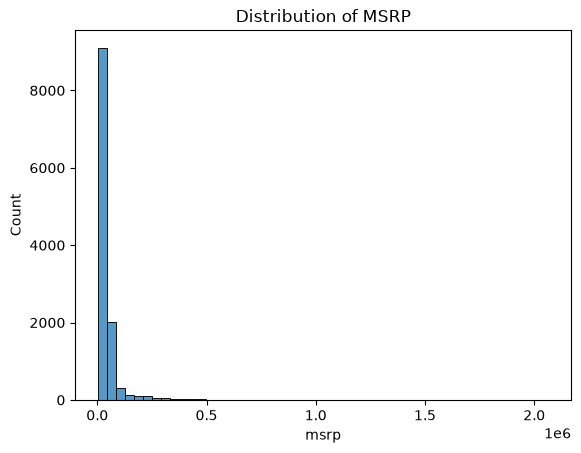

In [39]:
# Explore the target variable

sns.histplot(data=df.msrp, bins=50)
plt.title('Distribution of MSRP')

<Axes: xlabel='msrp', ylabel='Count'>

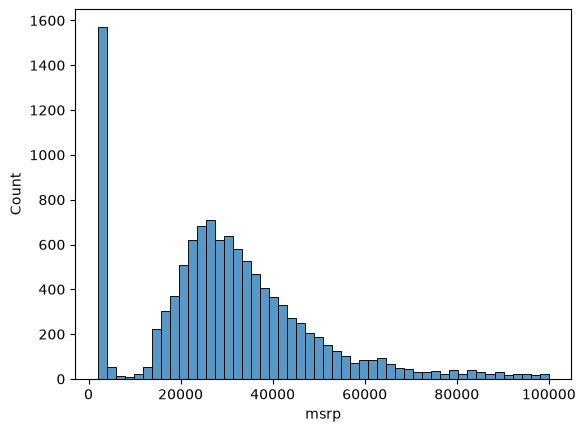

In [37]:
sns.histplot(data=df.msrp[df.msrp < 100000], bins=50)

Text(0.5, 1.0, 'Distribution of log(MSRP)')

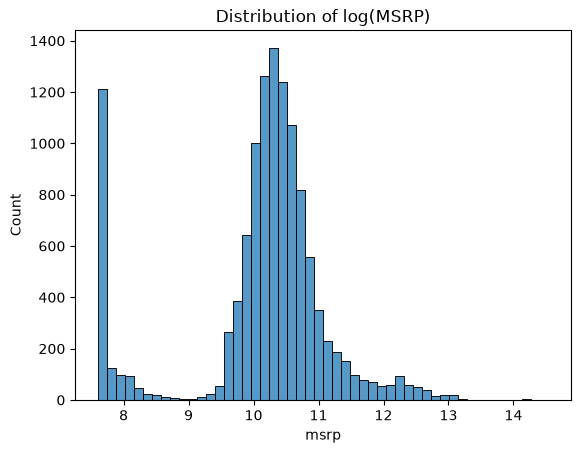

In [40]:
#
price_log = np.log1p(df.msrp)
sns.histplot(data=price_log, bins=50)
plt.title('Distribution of log(MSRP)')